## Simulate data based on half of one subject's data

In [1]:
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
df['RT'] = df['RT']*1000 # adjustment for RT
df['fixation'] = df['fixation'].apply(literal_eval)

In [3]:
sub_id = 301
sub_df = df.loc[df['sub_id'] == 301] # No dropped trials, second batch had less errors overall, more trials

odd_sub_df = sub_df.loc[sub_df['trial'] % 2 == 1]

We need the empirical distributions for this one subject:

In [67]:
bin_size = 1
value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fix_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

In [68]:
import simulation

empirical_distributions = simulation.get_empirical_distributions(
    sub_df, 
    bin_size, 
    value_diffs, 
    legend=legend, 
    fixation_col=fix_col, 
    v_left_col=left_value_col, 
    v_right_col=right_value_col,
    num_fix_dists=3,
    time_step=10,
    max_fix_time=3000
)

Discarding the top 5% of durations across all empirical distribution lists.

In [59]:
# Latencies
lst = sorted(empirical_distributions['latencies'])
empirical_distributions['latencies'] = lst[:int(len(lst) * 0.95)]

# Transitions
lst = sorted(empirical_distributions['transitions'])
empirical_distributions['transitions'] = lst[:int(len(lst) * 0.95)]

# Fixation 1

for key in list(empirical_distributions['fixations'][1].keys()):
    lst = sorted(empirical_distributions['fixations'][1][key])
    empirical_distributions['fixations'][1][key] = lst[:int(len(lst) * 0.95)]

# Fixation 2
for key in list(empirical_distributions['fixations'][2].keys()):
    lst = sorted(empirical_distributions['fixations'][2][key])
    empirical_distributions['fixations'][1][key] = lst[:int(len(lst) * 0.95)]

Let's build a function to capture the corrected empirical distributions for a subject

In [72]:
def get_corrected_subject_empirical_distributions(sub_id, sub_df):
    bin_size = 1
    value_diffs = np.arange(-4, 4.25, 0.25)
    legend = {
        "left": {1},
        "right": {2},
        "transition": {0}, 
        "blank_fixation": {4}
    }
    fix_col = 'fixation'
    left_value_col = 'avgWTP_left'
    right_value_col = 'avgWTP_right'

    empirical_distributions = simulation.get_empirical_distributions(
        sub_df, 
        bin_size, 
        value_diffs, 
        legend=legend, 
        fixation_col=fix_col, 
        v_left_col=left_value_col, 
        v_right_col=right_value_col,
        num_fix_dists=3,
        time_step=10,
        max_fix_time=3000
    )

    # Latencies
    lst = sorted(empirical_distributions['latencies'])
    empirical_distributions['latencies'] = lst[:int(len(lst) * 0.95)]

    # Transitions
    lst = sorted(empirical_distributions['transitions'])
    empirical_distributions['transitions'] = lst[:int(len(lst) * 0.95)]

    # Fixation 1

    for key in list(empirical_distributions['fixations'][1].keys()):
        lst = sorted(empirical_distributions['fixations'][1][key])
        empirical_distributions['fixations'][1][key] = lst[:int(len(lst) * 0.95)]

    # Fixation 2
    for key in list(empirical_distributions['fixations'][2].keys()):
        lst = sorted(empirical_distributions['fixations'][2][key])
        empirical_distributions['fixations'][1][key] = lst[:int(len(lst) * 0.95)]

    return empirical_distributions

Instead of using create trials from `simulation.py`, I will use `odd_sub_df` to act as a stand in. We'll need to clean things up and then generate fixations.

In [ ]:
odd_sub_df = sub_df.loc[sub_df['trial'] % 2 == 1]
trials = odd_sub_df[['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_13435/1454588748.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trials['fixation'] = None


In [70]:
bin_size = 0.001
seed = 42
model_conditions = {'drift_rate': 1.2, 'theta': 0.38, 'noise': 0.5}

In [36]:
import numpy as np

def generate_fixations(bin_size, relative_value_difference, empirical_distributions, total_duration_s=30.0, seed=42):
    """
    Return a tuple of event codes binned at `bin_size` seconds for `total_duration_s` seconds.
    Assumes empirical distributions may be in ms; converts to seconds.
    """
    rng = np.random.default_rng(seed)

    # --- Normalize units to seconds ---
    def to_seconds(arr):
        arr = np.asarray(arr)
        return arr / 1000.0 if np.median(arr) > 10 else arr

    latencies_s   = to_seconds(empirical_distributions['latencies'])
    transitions_s = to_seconds(empirical_distributions['transitions'])

    # fixations structure: {1: {rel_val: [durations]}, 2: {...}}
    # Convert all fixation durations to seconds, but preserve the dict shape.
    def fix_to_seconds(fix_dict):
        out = {}
        for rel_val, durations in fix_dict.items():
            out[rel_val] = to_seconds(durations)
        return out

    fix1 = fix_to_seconds(empirical_distributions['fixations'][1])
    fix2 = fix_to_seconds(empirical_distributions['fixations'][2])

    # Helper: get durations for a given rel_val with nearest-key fallback (floats as keys are brittle)
    def get_durations(dct, key):
        if key in dct:
            return dct[key]
        # nearest key fallback
        k = min(dct.keys(), key=lambda kk: abs(kk - key))
        return dct[k]

    # Pooled durations (abs value across signs)
    def pooled_fixation_durations(fixation_dict, abs_val):
        pool = []
        # exact match
        if  abs_val in fixation_dict:  pool.extend(fixation_dict[abs_val])
        if -abs_val in fixation_dict:  pool.extend(fixation_dict[-abs_val])
        # nearest-key fallback if pool empty
        if not len(pool):
            k1 = min(fixation_dict.keys(), key=lambda kk: abs(abs(kk) - abs_val))
            pool.extend(fixation_dict[k1])
        return np.asarray(pool)

    probLeftFirst = float(empirical_distributions['probFixLeftFirst'])
    left_first = rng.random() < probLeftFirst

    # First fixation sign selection
    rel_val_for_first = relative_value_difference if left_first else -relative_value_difference

    events = []  # (start_s, end_s, code)
    global_time = 0.0

    # Initial latency
    latency = rng.choice(latencies_s)
    events.append((global_time, global_time + latency, 0))
    global_time += latency

    # First fixation — sign dependent
    first_fixation_duration = rng.choice(get_durations(fix1, rel_val_for_first))
    code = 1 if left_first else 2
    events.append((global_time, global_time + first_fixation_duration, code))
    global_time += first_fixation_duration

    # Prepare for alternation
    current_side_code = 2 if code == 1 else 1
    abs_val = abs(relative_value_difference)

    # Subsequent fixations — pooled
    # Guard against empty transitions or pooled durations
    if len(transitions_s) == 0:
        raise ValueError("empirical_distributions['transitions'] is empty after unit conversion.")
    pooled2 = pooled_fixation_durations(fix2, abs_val)
    if len(pooled2) == 0:
        raise ValueError("No pooled fixation durations for subsequent fixations.")

    while global_time < total_duration_s:
        # Transition
        tdur = rng.choice(transitions_s)
        start = global_time
        end   = min(global_time + tdur, total_duration_s)
        events.append((start, end, 0))
        global_time = end
        if global_time >= total_duration_s: break

        # Fixation
        fdur = rng.choice(pooled2)
        start = global_time
        end   = min(global_time + fdur, total_duration_s)
        events.append((start, end, current_side_code))
        global_time = end

        # Alternate side
        current_side_code = 2 if current_side_code == 1 else 1

    # Bin to fixed time grid in seconds
    num_bins = int(np.floor(total_duration_s / bin_size))
    fixation_sequence = []
    # Sweep through events once (O(Nbins + Nevents))
    e_idx = 0
    for i in range(num_bins):
        t = i * bin_size
        # advance event pointer
        while e_idx < len(events) and not (events[e_idx][0] <= t < events[e_idx][1]):
            e_idx += 1
        if e_idx < len(events) and events[e_idx][0] <= t < events[e_idx][1]:
            fixation_sequence.append(events[e_idx][2])
        else:
            fixation_sequence.append(0)

    return tuple(fixation_sequence)


In [11]:
trials['fixation'] = trials.apply(
    lambda r: generate_fixations(bin_size, r['avgWTP_left'] - r['avgWTP_right'], empirical_distributions),
    axis=1
)

/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_13435/1316111179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trials['fixation'] = trials.apply(


In [12]:
trials.head()

,avgWTP_left,avgWTP_right,fixation
6440,3.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6442,1.50,3.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6444,1.25,1.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6446,2.50,2.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6448,3.00,3.25,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
my_trials = trials.to_dict(orient="records")

## Simulate trials

In [ ]:
results_df = simulation.simulate(bin_size, model_conditions, my_trials, seed=seed, save_results=False)

In [23]:
results_df['sub_id'] = str(sub_id) + '_sim'
results_df['trial'] = range(1, len(trials) + 1)
results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
results_df = results_df.drop(columns = ['trajectory'])
results_df.head()

,avgWTP_left,avgWTP_right,fix_sequence,RT,choice,sub_id,trial
0,3.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.882,1,301_sim,1
1,1.50,3.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.942,1,301_sim,2
2,1.25,1.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.899,1,301_sim,3
3,2.50,2.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.523,1,301_sim,4
4,3.00,3.25,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.388,1,301_sim,5


## Rerasterize simulated data

In [24]:
import mfa
from pyddm.preprocessing.dataset import rasterize_data

trials_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fix_sequence')

In [25]:
trials_rasterized.head()

,avgWTP_left,avgWTP_right,RT,choice,sub_id,trial,fix_start,fix_end,fix_location
0,3.00,1.00,0.882,1,301_sim,1,206,661,2
1,1.50,3.50,0.942,1,301_sim,2,204,941,1
2,1.25,1.75,0.899,1,301_sim,3,170,687,1
3,1.25,1.75,0.899,1,301_sim,3,698,898,2
4,2.50,2.50,0.523,1,301_sim,4,194,522,2


The following should be turned into a function and reworked into the pipeline. We need to create fix_num, fix_num_rev, fix_dur.

In [26]:
trials_rasterized['fix_dur'] = trials_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

trials_rasterized['fix_num'] = (
    trials_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

trials_rasterized['fix_num_rev'] = (
    trials_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

In [27]:
trials_rasterized.head()

,avgWTP_left,avgWTP_right,RT,choice,sub_id,trial,fix_start,fix_end,fix_location,fix_dur,fix_num,fix_num_rev
0,3.00,1.00,0.882,1,301_sim,1,206,661,2,455,1,1
1,1.50,3.50,0.942,1,301_sim,2,204,941,1,737,1,1
2,1.25,1.75,0.899,1,301_sim,3,170,687,1,517,1,2
3,1.25,1.75,0.899,1,301_sim,3,698,898,2,200,2,1
4,2.50,2.50,0.523,1,301_sim,4,194,522,2,328,1,1


/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

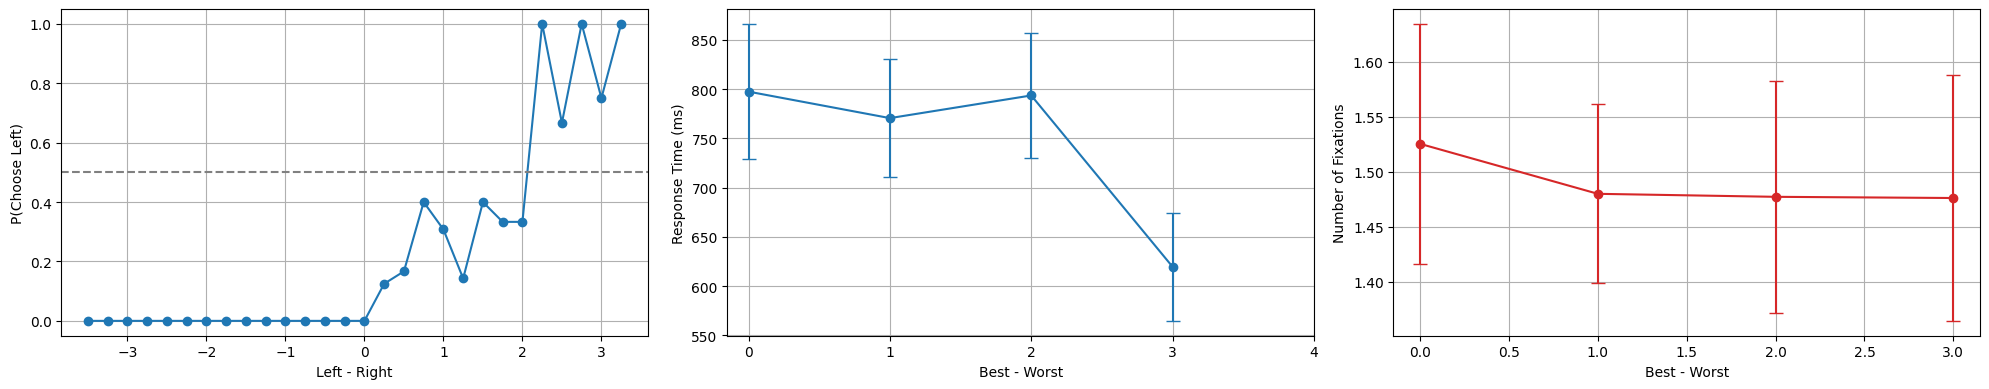

In [28]:
mfa.plot_basic_psychometrics(trials_rasterized)

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('di

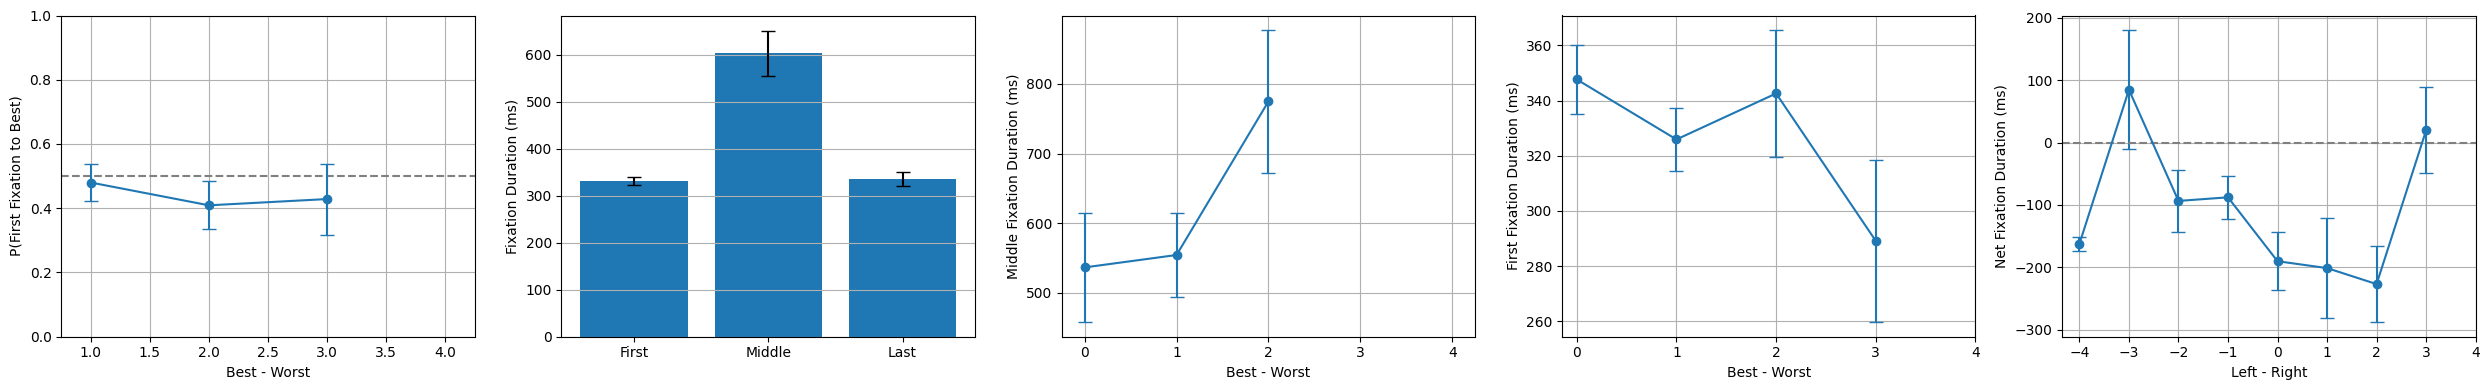

In [29]:
mfa.plot_fixation_properties(trials_rasterized)

We've seen it once. Now let's do it as a function:

In [75]:
def plot_simulated_data(model_conditions, bin_size, empirical_distributions):
    def generate_fixations(bin_size, relative_value_difference, empirical_distributions, total_duration_s=30.0, seed=42):
        """
        Return a tuple of event codes binned at `bin_size` seconds for `total_duration_s` seconds.
        Assumes empirical distributions may be in ms; converts to seconds.
        """
        rng = np.random.default_rng(seed)

        # --- Normalize units to seconds ---
        def to_seconds(arr):
            arr = np.asarray(arr)
            return arr / 1000.0 if np.median(arr) > 10 else arr

        latencies_s   = to_seconds(empirical_distributions['latencies'])
        transitions_s = to_seconds(empirical_distributions['transitions'])

        # fixations structure: {1: {rel_val: [durations]}, 2: {...}}
        # Convert all fixation durations to seconds, but preserve the dict shape.
        def fix_to_seconds(fix_dict):
            out = {}
            for rel_val, durations in fix_dict.items():
                out[rel_val] = to_seconds(durations)
            return out

        fix1 = fix_to_seconds(empirical_distributions['fixations'][1])
        fix2 = fix_to_seconds(empirical_distributions['fixations'][2])

        # Helper: get durations for a given rel_val with nearest-key fallback (floats as keys are brittle)
        def get_durations(dct, key):
            if key in dct:
                return dct[key]
            # nearest key fallback
            k = min(dct.keys(), key=lambda kk: abs(kk - key))
            return dct[k]

        # Pooled durations (abs value across signs)
        def pooled_fixation_durations(fixation_dict, abs_val):
            pool = []
            # exact match
            if  abs_val in fixation_dict:  pool.extend(fixation_dict[abs_val])
            if -abs_val in fixation_dict:  pool.extend(fixation_dict[-abs_val])
            # nearest-key fallback if pool empty
            if not len(pool):
                k1 = min(fixation_dict.keys(), key=lambda kk: abs(abs(kk) - abs_val))
                pool.extend(fixation_dict[k1])
            return np.asarray(pool)

        probLeftFirst = float(empirical_distributions['probFixLeftFirst'])
        left_first = rng.random() < probLeftFirst

        # First fixation sign selection
        rel_val_for_first = relative_value_difference if left_first else -relative_value_difference

        events = []  # (start_s, end_s, code)
        global_time = 0.0

        # Initial latency
        latency = rng.choice(latencies_s)
        events.append((global_time, global_time + latency, 0))
        global_time += latency

        # First fixation — sign dependent
        first_fixation_duration = rng.choice(get_durations(fix1, rel_val_for_first))
        code = 1 if left_first else 2
        events.append((global_time, global_time + first_fixation_duration, code))
        global_time += first_fixation_duration

        # Prepare for alternation
        current_side_code = 2 if code == 1 else 1
        abs_val = abs(relative_value_difference)

        # Subsequent fixations — pooled
        # Guard against empty transitions or pooled durations
        if len(transitions_s) == 0:
            raise ValueError("empirical_distributions['transitions'] is empty after unit conversion.")
        pooled2 = pooled_fixation_durations(fix2, abs_val)
        if len(pooled2) == 0:
            raise ValueError("No pooled fixation durations for subsequent fixations.")

        while global_time < total_duration_s:
            # Transition
            tdur = rng.choice(transitions_s)
            start = global_time
            end   = min(global_time + tdur, total_duration_s)
            events.append((start, end, 0))
            global_time = end
            if global_time >= total_duration_s: break

            # Fixation
            fdur = rng.choice(pooled2)
            start = global_time
            end   = min(global_time + fdur, total_duration_s)
            events.append((start, end, current_side_code))
            global_time = end

            # Alternate side
            current_side_code = 2 if current_side_code == 1 else 1

        # Bin to fixed time grid in seconds
        num_bins = int(np.floor(total_duration_s / bin_size))
        fixation_sequence = []
        # Sweep through events once (O(Nbins + Nevents))
        e_idx = 0
        for i in range(num_bins):
            t = i * bin_size
            # advance event pointer
            while e_idx < len(events) and not (events[e_idx][0] <= t < events[e_idx][1]):
                e_idx += 1
            if e_idx < len(events) and events[e_idx][0] <= t < events[e_idx][1]:
                fixation_sequence.append(events[e_idx][2])
            else:
                fixation_sequence.append(0)

        return tuple(fixation_sequence)
    
    trials['fixation'] = trials.apply(
        lambda r: generate_fixations(bin_size, r['avgWTP_left'] - r['avgWTP_right'], empirical_distributions, seed=seed),
        axis=1,
    )

    my_trials = trials.to_dict(orient="records")
    results_df = simulation.simulate(bin_size, model_conditions, my_trials, seed=seed, save_results=False)

    results_df['sub_id'] = str(sub_id) + '_sim'
    results_df['trial'] = range(1, len(trials) + 1)
    results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    trials_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fix_sequence')

    trials_rasterized['fix_dur'] = trials_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    trials_rasterized['fix_num'] = (
        trials_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    trials_rasterized['fix_num_rev'] = (
        trials_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )
        
    mfa.plot_basic_psychometrics(trials_rasterized)
    mfa.plot_fixation_properties(trials_rasterized)

## Tidy Workflow

In [73]:
sub_id = 301
sub_df = df.loc[df['sub_id'] == sub_id]
sub_empirical_distributions = get_corrected_subject_empirical_distributions(sub_id, sub_df)

In [76]:
bin_size = 0.001
model_conditions = {'drift_rate': 1.3, 'theta': 0.51, 'noise': 0.66}

plot_simulated_data(model_conditions, bin_size, sub_empirical_distributions)

/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: a cannot be empty unless no samples are taken